# Short Cantilever

This is an interactive Jupyter Notebook implementation.

In [1]:
import dolfin as df
from dolfin_adjoint import Constant, DirichletBC, RectangleMesh, stop_annotating
import numpy as np
import gemseo
from gemseo import create_scenario
from samo_ggp.geometry.factory import GeometryFactory
from samo_ggp.physics.factory import PhysicsFactory
from samo_ggp.gemseo_wrappers.macro_discipline import GGPMacroDiscipline
import matplotlib.pyplot as plt
import os

In [2]:
def run_short_cantilever():
    L, H = 50.0, 50.0
    nelx, nely = 50, 50
    volfrac = 0.4
    num_components = 10

    # Mesh and Spaces
    mesh = RectangleMesh(df.Point(0, 0), df.Point(L, H), nelx, nely)
    V_u = df.VectorFunctionSpace(mesh, "CG", 1)
    
    # Boundary Conditions: Left edge fixed
    def left_boundary(x, on_boundary): return on_boundary and df.near(x[0], 0.0)
    bc = [DirichletBC(V_u, Constant((0.0, 0.0)), left_boundary)]
    
    # Load: Point load on middle right
    boundaries = df.MeshFunction("size_t", mesh, mesh.topology().dim() - 1)
    boundaries.set_all(0)
    class MiddleRightArea(df.SubDomain):
        def inside(self, x, on_boundary): return df.near(x[0], L, 2.0) and df.near(x[1], H/2.0, 5.0)
    MiddleRightArea().mark(boundaries, 1)
    ds_load = df.Measure("ds", domain=mesh, subdomain_data=boundaries)
    L_rhs_vec = Constant((0.0, -1.0))

    # Initialization
    mapper = GeometryFactory.create_mapper("2D_Free", mesh=mesh, num_components=num_components)
    solver = PhysicsFactory.create_solver("Elasticity_2D", V_u=V_u, bc=bc, ds_load=ds_load, L_rhs_vec=L_rhs_vec)
    x_init = mapper.get_initial_design(L, H)
    lb = np.array([0.0, 0.0, 5.0, 2.0, -np.pi] * num_components)
    ub = np.array([L, H, L, H/2, np.pi] * num_components)

    # Discipline and Optimization
    disc = GGPMacroDiscipline(mapper, solver, x_init, lb, ub, mesh_area=L*H, name="GGP_Short_Cantilever")
    design_space = gemseo.algos.design_space.DesignSpace()
    design_space.add_variable("x_vars", size=len(x_init), lower_bound=lb, upper_bound=ub, value=x_init)
    
    scenario = create_scenario(disciplines=[disc], objective_name="compliance", design_space=design_space, formulation_name="DisciplinaryOpt")
    scenario.add_constraint("volume", "ineq", positive=False, value=volfrac)
    
    scenario.execute(algo_name="MMA", max_iter=5, max_optimization_step=0.1)

    # --- Post-Processing ---
    print("Post-processing optimal design...")
    os.makedirs("results", exist_ok=True)
    
    # 1. Retrieve optimal design variables from GEMSEO
    opt_x = scenario.optimization_result.x_opt
    
    # 2. Assign back to FEniCS constants to update the UFL graph
    for c, v in zip(disc.controls_objs, opt_x):
        c.assign(float(v))
        
    with stop_annotating():
        # 3. Recompute the density field and project to a Function Space
        V_rho = df.FunctionSpace(mesh, "CG", 1)
        rho_opt_ufl = mapper.map_to_density(disc.controls_objs)
        rho_opt = df.project(rho_opt_ufl, V_rho)
        rho_opt.rename("Density", "Optimized GGP Density")
        
        # 4. Save to Paraview format (.pvd)
        df.File("results/short_cantilever_optimized.pvd") << rho_opt
        
        # 5. Save PNG using Matplotlib
        plt.figure(figsize=(6, 5))
        p = df.plot(rho_opt, cmap="Blues")
        plt.colorbar(p, label="Density $\\rho$")
        plt.title("Optimized GGP Topology: Short Cantilever")
        plt.savefig("results/short_cantilever_optimized.png", dpi=300, bbox_inches="tight")
        print("Results saved to 'results/' directory.")

    INFO - 21:54:07: *** Start MDOScenario execution ***


    INFO - 21:54:07: MDOScenario


    INFO - 21:54:07:    Disciplines: GGP_Short_Cantilever


    INFO - 21:54:07:    MDO formulation: DisciplinaryOpt


    INFO - 21:54:07: Optimization problem:


...

    INFO - 21:55:08:       Standardized constraints:


    INFO - 21:55:08:          [volume-0.4] = -0.07286574826274778


    INFO - 21:55:08: *** End MDOScenario execution ***


Post-processing optimal design...


Results saved to 'results/' directory.


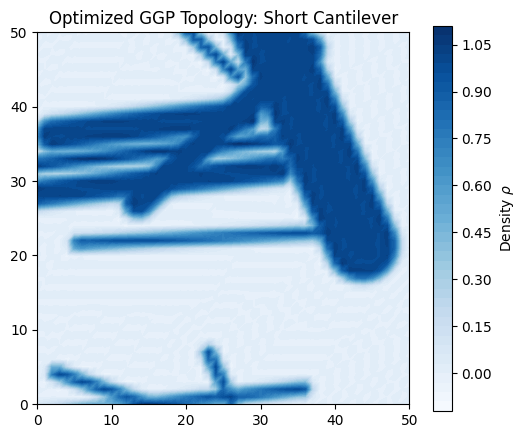

In [3]:
if __name__ == "__main__":
    run_short_cantilever()

### Optimized Result\n\n![Optimized Design](_static/short_cantilever_optimized.png)